<hr/>

# [Generalized Linear Mixed Models](https://donnievin.github.io/ASDA_2/)
By: **Donovan Vincent Jr** - dvincen9@jh.edu <br/>
Adapted From: **Dr. Sergey Kushnarev's ASDA II** <br/>
Estimated Workthrough Time: **90 mins**

<hr/>

<h1><font color="blue">Binomial Models: Symmetric PDFs</font></h1>

Topics: 
* Grouped vs Ungrouped
* Threshold Model
* Logistic Model
* Classification Table

In [4]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import scipy.stats as stats
import statsmodels.api as sm # https://www.statsmodels.org/stable/datasets/index.html
import statsmodels.formula.api as smf


# <font color='lightblue'> Grouped vs Ungrouped </font>

> Problem Set Up

Binary Data is data where we label 1 as success and 0 as a failure. Our goal is to estimate the `probability of success`, $\pi_i$, after observing $n_i$ `trials`.

<div align="center">

$$
S_i \sim Binomial(n_i, \pi_i)
$$

$$
S_i = n_i y_i
$$

$$
y_i \sim \frac{1}{n_i} Binomial(n_i, \pi_i)
$$

</div>

where 
* $S_i$ = the <font color='red'> number</font> of successes in $n_i$ trials for obseration i   <font color='red'> NOTE</font>:  $S_i \in \{0, 1, ... , n_i\}$
* $n_i$ = the total number of observations 
* $y_i$ = the <font color='red'> proportion</font> of successes in $n_i$ trials for observatoin i <font color='red'> NOTE</font>: $y_i \in [0,1]$ 

--- 


> Data Structures

* <font color='blue'>Ungrouped Data</font>: Each $n_i$ is a single Bernoulli trail [0 or 1] $\implies N = (0, 1, 1, 0, 1, ..., 0)$
* <font color='darkgreen'>Grouped Data</font>: Each $n_i$ has at least 2 Bernoulli observations $\implies N = (n_1, n_2, n_3, ..., n_n)$
* In both cases: $y_i = \frac{S_i}{n_i}$. However, for <font color='blue'>Ungrouped</font> data this gives values of <font color='blue'>0 or 1</font> (since $n_i=1$) but for <font color='darkgreen'>Grouped data</font> this gives from <font color='darkgreen'>0 to 1</font>.

--- 

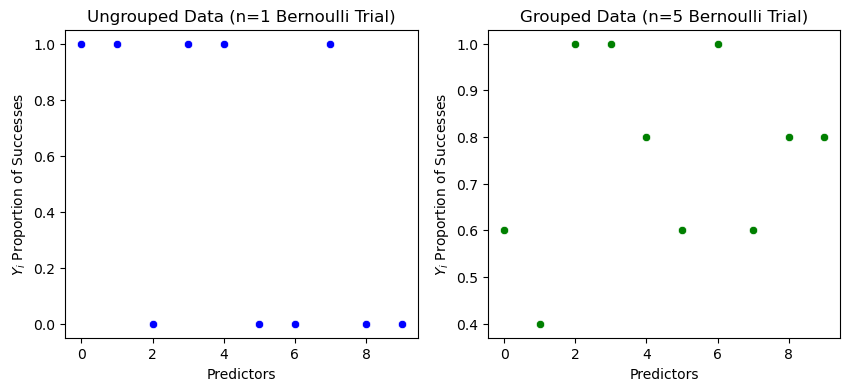

In [14]:
np.random.seed(31100)
x = np.arange(0,10)

ungrouped_data = np.random.binomial(n=1, p=0.7, size=len(x))
grouped_data = np.random.binomial(n=5, p=0.7, size=len(x)) # Prints the number of successes out of n=5 trials

# yi = Si / ni
yi_ungrouped = ungrouped_data / 1 
yi_grouped = grouped_data / 5 


# Graph ungrouped and grouped side by side
fig, axes = plt.subplots(1,2, figsize=(10,4))

sns.scatterplot(x=x, y=yi_ungrouped, color='blue', ax=axes[0])
axes[0].set_xlabel("Predictors")
axes[0].set_ylabel(r"$Y_i$ Proportion of Successes")
axes[0].set_title("Ungrouped Data (n=1 Bernoulli Trial)")

sns.scatterplot(x=x, y=yi_grouped, color='green', ax=axes[1])
axes[1].set_xlabel("Predictors")
axes[1].set_ylabel(r"$Y_i$ Proportion of Successes")
axes[1].set_title("Grouped Data (n=5 Bernoulli Trial)")

plt.show()



# <font color='lightblue'> Threshold Models (Latent Variable Model) </font>

> Intuition

There is a latent (unobserved) continuous random variable $y^*$ such that: 

<div align="center">

$$
y^* > \tau \implies Y_i=1
$$

</div>


--- 

> Goal

* We want to model $\pi_i = Pr(Y_i=1)$.

---

> Derivation 

* From above, we know that $Y_i=1$ when $y_i^* > \tau \implies \pi_i = Pr(y_i^* > \tau)$
* This is one of those problems where its easier to model the chance of failure: $\pi_i = 1 - Pr(y_i^* \leq \tau)$
* Substitute in the definition of $y_i^* \implies \pi_i = 1 - Pr(\sum_{j=1}^p X_{ij} \beta_j \leq \tau)$ 
* Rewrite: $\pi_i = 1 - Pr(\epsilon \leq \tau - \sum_{j=1}^p X_{ij} \beta_j)$
* Plug in CDF definition: $\pi_i = 1 - F(\tau - \sum_{j=1}^p X_{ij} \beta_j)$
* Assume symmetric PDF, so $1 - F(-z) = F(z) $

<div align="center">

$$
\pi_i = F(\sum_{j=1}^p X_{ij} \beta_j)
$$

</div>

---

> Final Steps 

<div align="center">

$$
F^{-1}(\pi_i) = \sum_{j=1}^p X_{ij} \beta_j
$$

</div>

---

> Link function 

Here, our link function, $g(\mu) = \eta = \sum_{j=1}^p X_{ij} \beta_j$, is the INVERSE CDF (we can choose any CDF). This makes sense as $F: (-\infty, \infty) \to [0,1]$

Examples: 
* Probit Regression = CDF of Standard Normal: $\pi_i = \Phi(\sum_{j=1}^p X_{ij}\beta_j)$
* Logistic (log odds) Regression = Logistic CDF with SD=1: $F(z) = \frac{e^z}{1+ e^z} \implies \pi_i = F(\sum_{j=1}^p X_{ij} \beta_j)$
* Linear (uniform) Regression = $F(z) = z \implies \pi_i = F(\sum_{j=1}^p X_{ij} \beta_j) $

# <font color='lightblue'> Logistic Model </font>

We can model the probability density function (PDF) / probability mass functions (PMF) of a variety of of distributions using a common form where Y can be sampled from an exponential dispersion family: $Y_i \sim EDF(\theta_i, \phi_i)$. Their probability functions can be written using the following form:


<div align="center">

$$
f(y_i | \theta_i, \phi_i) = exp[ \frac{y_i \theta_i - b(\theta_i)}{a(\phi)} + c(y_i, \theta_i)]
$$

</div>


where:
* $\theta_i$ = Natural Parameter
* $b(\theta_i)$ = cumulant function
* $\phi_i$ = Dispersion parameter
* $c(y_i, \theta_i)$ = ???

# <font color='lightblue'> Classification Table </font>

|          |$\hat{Y}=0$    |   $\hat{Y}=1$ |
|:---------|:-------------:|:-------------:|
| $Y=0$| <font color='red'>TNR</font>|<font color='red'>FPR</font>|
| $Y=1$| <font color='red'>FNR</font>|<font color='red'>TPR</font>|


* <font color='red'>True Negative Rate (Specificity)</font> $Pr(\hat{Y}=0 | Y=0)$: This is the probability of the model predicting false, given that the data point was actually false
* <font color='red'>True Negative Rate (Specificity)</font> $Pr(\hat{Y}=0 | Y=0)$: This is the probability of the model predicting false, given that the data point was actually false
* <font color='red'>True Negative Rate (Specificity)</font> $Pr(\hat{Y}=0 | Y=0)$: This is the probability of the model predicting false, given that the data point was actually false
* <font color='red'>True Negative Rate (Specificity)</font> $Pr(\hat{Y}=0 | Y=0)$: This is the probability of the model predicting false, given that the data point was actually false
                 


# Further References

1. [Chapter 5:](https://download.e-bookshelf.de/download/0003/0821/70/L-G-0003082170-0005968026.pdf) Foundations of Linear and Generalized Linear Models